In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import colormaps as cm
import pandas as pd

from graphufs.stacked_utils import get_channel_index

from graphcast.model_utils import dataset_to_stacked

In [2]:
# meta data
_scratch = "/pscratch/sd/n/nagarwal/"
_prototype = "ocn-only"
_expt = "R4"
_inference_dir = os.path.join(_scratch, _prototype, _expt,
                              "inference_T3M", "validation")

In [3]:
# GraphUFS predictions
fname = "graphufs.240h.zarr"
ds_pred = xr.open_zarr(os.path.join(_inference_dir, fname))
ds_pred

<xarray.Dataset> Size: 175GB
Dimensions:    (time: 513, lead_time: 40, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 days 0...
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 4kB 2022-01-01 ... 2023-10-03
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (time, lead_time, lat, lon) float32 6GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    so         (time, lead_time, z_l, lat, lon) float32 42GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    temp       (time, lead_time, z_l, lat, lon) float32 42GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    uo         (time, lead_time, z_l, lat, lon) float32 42GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>
    vo         (time, lead_time, z_l, lat, lon) float32 42GB dask.array<chunksize=(1, 40, 7, 192, 384), meta=np.ndarray>

In [4]:
# Replay targets
fname = "replay.240h.zarr"
ds_tar = xr.open_zarr(os.path.join(_inference_dir, fname))
ds_tar

<xarray.Dataset> Size: 345GB
Dimensions:    (time: 513, lead_time: 40, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 days 0...
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 4kB 2022-01-01 ... 2023-10-03
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (time, lead_time, lat, lon) float32 6GB dask.array<chunksize=(1, 40, 192, 384), meta=np.ndarray>
    so         (time, z_l, lead_time, lat, lon) float64 85GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>
    temp       (time, z_l, lead_time, lat, lon) float64 85GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>
    uo         (time, z_l, lead_time, lat, lon) float64 85GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>
    vo         (time, z_l, lead_time, lat, lon) float64 85GB dask.array<chunksize=(1, 7, 40, 192, 384), meta=np.ndarray>

In [5]:
# channel meta
meta = get_channel_index(ds_pred, preserved_dims=("time","lead_time","lat","lon"))

## Forecast Error

In [6]:
def compute_forecast_error_ds(prediction: xr.Dataset, target: xr.Dataset, 
                              kind: str = "difference") -> xr.Dataset:
    """
    Compute forecast error between prediction and target datasets.

    Args:
        prediction (xr.Dataset): Dataset of predicted variables.
        target (xr.Dataset): Dataset of target (truth) variables.
        kind (str): Type of error to compute. Options:
            - "difference" (default): prediction - target
            - "absolute": |prediction - target|
            - "squared": (prediction - target)^2

    Returns:
        xr.Dataset: Dataset containing forecast error for each common variable.
    """
    # Ensure we are working only with variables common to both datasets
    common_vars = list(set(prediction.data_vars).intersection(target.data_vars))

    error_vars = {}
    dims_to_avg = ["lat", "lon", "grid_xt", "grid_yt",]

    for var in common_vars:
        pred = prediction[var]
        targ = target[var]

        if kind == "difference":
            error = pred - targ
        elif kind == "absolute":
            error = abs(pred - targ)
        elif kind == "squared":
            error = (pred - targ) ** 2
        else:
            raise ValueError(f"Unknown error kind: {kind}")

        error.name = f"{var}_error"

        dims = [dim for dim in dims_to_avg if dim in error.dims]

        if len(dims)>0:
            error_vars[error.name] = error.mean(dim=dims)
        else:
            error_vars[error.name] = error

    return xr.Dataset(error_vars)

In [7]:
# forecast error
error_ds = compute_forecast_error_ds(ds_pred, ds_tar, kind="squared").compute()
print(error_ds)

<xarray.Dataset> Size: 5MB
Dimensions:     (lead_time: 40, time: 513, z_l: 7)
Coordinates:
  * lead_time   (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 days ...
  * time        (time) datetime64[ns] 4kB 2022-01-01 ... 2023-10-03
  * z_l         (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    temp_error  (time, lead_time, z_l) float64 1MB 0.00459 0.0005741 ... 0.07106
    uo_error    (time, lead_time, z_l) float64 1MB 0.0003646 ... 0.008329
    so_error    (time, lead_time, z_l) float64 1MB 0.003332 ... 0.0008987
    SSH_error   (time, lead_time) float32 82kB 8.192e-05 0.0001806 ... 0.0167
    vo_error    (time, lead_time, z_l) float64 1MB 0.0003864 ... 0.004812


In [8]:
error_ds_stacked = dataset_to_stacked(error_ds, preserved_dims=("time", "lead_time",))
error_ds_stacked

<xarray.DataArray (time: 513, lead_time: 40, channels: 29)> Size: 5MB
array([[[8.19221314e-05, 3.33196407e-03, 3.24793444e-03, ...,
         3.72014813e-05, 2.14023895e-05, 1.60363412e-05],
        [1.80575997e-04, 9.58462218e-03, 1.40723954e-02, ...,
         7.45717169e-05, 4.51291201e-05, 3.41069535e-05],
        [3.01018852e-04, 1.93218117e-02, 3.22371167e-02, ...,
         1.42346754e-04, 8.63453216e-05, 6.65042527e-05],
        ...,
        [1.55160874e-02, 3.39757271e+00, 3.80078532e+00, ...,
         6.74213293e-03, 5.34621976e-03, 4.60610845e-03],
        [1.63825825e-02, 3.60221261e+00, 4.02484721e+00, ...,
         7.11700192e-03, 5.66604690e-03, 4.88655610e-03],
        [1.71798151e-02, 3.83110017e+00, 4.23278123e+00, ...,
         7.43467645e-03, 5.93017157e-03, 5.12463369e-03]],

       [[9.61166224e-05, 3.49719550e-03, 4.99971627e-03, ...,
         4.17662550e-05, 2.48415847e-05, 1.93548285e-05],
        [2.15510008e-04, 1.03873863e-02, 1.74615402e-02, ...,
         8.83072216e-05, 5.13535146e-05, 3.93419703e-05],
        [3.63493629e-04, 2.06332922e-02, 3.44322703e-02, ...,
         1.48712382e-04, 9.01802176e-05, 6.75666018e-05],
...
         6.23529971e-03, 4.91900662e-03, 4.30554358e-03],
        [1.54288840e-02, 4.23549441e+00, 4.19675790e+00, ...,
         6.64183331e-03, 5.25408769e-03, 4.55934386e-03],
        [1.63334347e-02, 4.48147771e+00, 4.43737172e+00, ...,
         6.97820258e-03, 5.54902999e-03, 4.81396778e-03]],

       [[1.21895544e-04, 3.43981422e-03, 3.35968568e-03, ...,
         4.52520609e-05, 2.57015682e-05, 1.95835422e-05],
        [2.65219540e-04, 1.00447421e-02, 1.47244496e-02, ...,
         7.93225219e-05, 4.79285732e-05, 3.76559805e-05],
        [3.67254601e-04, 2.09070597e-02, 3.37115419e-02, ...,
         1.43804441e-04, 8.96672640e-05, 7.13519396e-05],
        ...,
        [1.50997872e-02, 3.96332314e+00, 3.92174404e+00, ...,
         6.29493173e-03, 5.00709644e-03, 4.32768392e-03],
        [1.60006434e-02, 4.20660155e+00, 4.15566648e+00, ...,
         6.63932164e-03, 5.29652317e-03, 4.57699915e-03],
        [1.66999828e-02, 4.48201233e+00, 4.37071843e+00, ...,
         6.95873628e-03, 5.55715188e-03, 4.81205191e-03]]],
      shape=(513, 40, 29))
Coordinates:
  * lead_time  (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 days 0...
  * time       (time) datetime64[ns] 4kB 2022-01-01 ... 2023-10-03
Dimensions without coordinates: channels

## Error Covariance

In [9]:
def cross_covariance(da: xr.DataArray, dim: str = "channels", norm = False):
  """
  Calculates the cross-covariance matrix for all pairs along dim.

  Args:
    da (xr.DataArray): The input DataArray.
    dim (str): The shared dimension along which variables are defined.
    norm (bool): If true, normalization by std will be applied to compute correlation

  Returns:
    xr.DataArray: A DataArray containing the cov/corr matrix.
  """

  channels = da[dim]  # Get the dim values
    
  out_mat = np.zeros((len(channels), len(channels)))
  
  for i in range(len(channels)):
    for j in range(i, len(channels)):

      channel_i = channels[i]
      channel_j = channels[j]

      # Calculate covariance
      if not norm:
          out_mat[i, j] = xr.cov(da.isel({dim:channel_i}), da.isel({dim:channel_j})).compute()
          statistic = "covariance"
      else:
          out_mat[i, j] = xr.corr(da.isel({dim:channel_i}), da.isel({dim:channel_j})).compute()
          statistic = "correlation"
          
      # apply symmetry
      out_mat[j, i] = out_mat[i, j].copy()

  # convert to dataArray
  out_da = xr.DataArray(out_mat, dims=["channels_x","channels_y"], coords={"channels_x":channels.values, "channels_y":channels.values}, 
                        attrs={"description":f"forecast error cross-{statistic} for the R4/T3M ocn-only configuration (trained with correct statistics)"})
  return out_da

In [10]:
# error covariance across channels
error_cov = cross_covariance(error_ds_stacked, dim="channels")

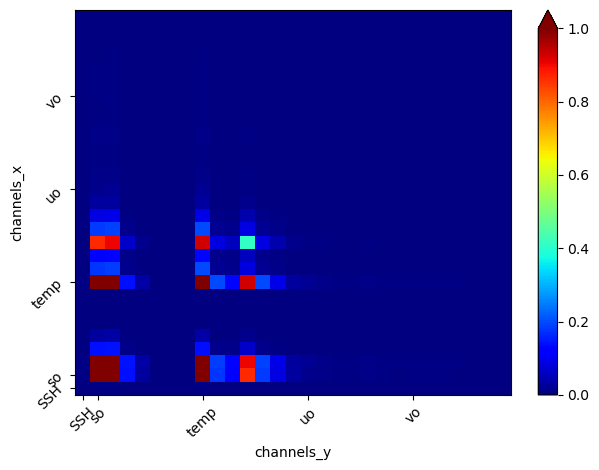

In [15]:
# plot
error_cov.plot(vmin=0., vmax=1, cmap="jet")
ax = plt.gca()
ticks = (0, 1, 8, 15, 22)
ticklabels = [meta[i]["varname"] for i in ticks]
ax.set_xticks(ticks,); ax.set_yticks(ticks,)
ax.set_xticklabels(ticklabels,); ax.set_yticklabels(ticklabels,)
ax.tick_params(labelrotation=45)
plt.savefig(f"figures/forecast_error_covariance_{_prototype}_{_expt}_T3M.png", dpi=300)
plt.tight_layout()
plt.show()

## Error Correlation

In [13]:
# error covariance across channels
error_corr = cross_covariance(error_ds_stacked, dim="channels", norm=True)

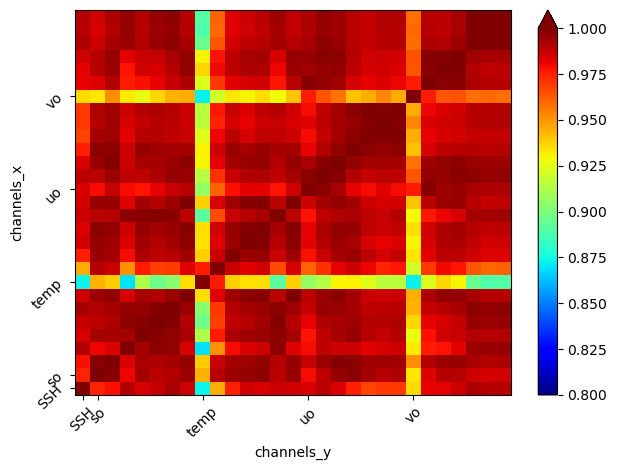

In [17]:
# plot
error_corr.plot(cmap="jet", vmin=0.8, vmax=1)
ax = plt.gca()
ticks = (0, 1, 8, 15, 22)
ticklabels = [meta[i]["varname"] for i in ticks]
ax.set_xticks(ticks,); ax.set_yticks(ticks,)
ax.set_xticklabels(ticklabels,); ax.set_yticklabels(ticklabels,)
ax.tick_params(labelrotation=45)
plt.savefig(f"figures/forecast_error_correlation_{_prototype}_{_expt}_T3M.png", dpi=300)
plt.tight_layout()
plt.show()